Fáza 2 - Predspracovanie údajov

In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    Normalizer,
    LabelEncoder
)
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    VarianceThreshold
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path

path = Path("../data/cleaned_data")

observation_df = pd.read_csv(path / "observation.csv")
patient_df = pd.read_csv(path / "patient.csv")
station_df = pd.read_csv(path / "station.csv")

In [113]:
station_df["revision"] = pd.to_datetime(station_df["revision"], errors="coerce")
station_df["revision"] = station_df["revision"].astype("int64") // 10**9  

le = LabelEncoder()
for col in ["station", "continent", "city", "QoS"]:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna("Missing")
        station_df[col] = le.fit_transform(station_df[col].astype(str))

display(station_df.head())

,station,longitude,QoS,latitude,revision,continent,city
0,224,86.51499,2,23.19590,1529193600,4,57
1,72,-83.48216,2,42.30865,1665360000,1,32
2,513,84.87144,2,47.46657,1478390400,4,4
3,415,30.38167,2,59.80917,1662768000,6,81
4,85,2.95924,2,36.76775,1704585600,0,3


In [114]:
merged_df = pd.merge(
    observation_df,
    station_df,
    on=["latitude", "longitude"],
    how="left"
)

print("Non-null station data:", merged_df['station'].notna().mean() * 100, "%")

Non-null station data: 100.0 %


In [115]:
X = merged_df.drop('oximetry', axis=1)
y = merged_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(17260, 27) (4315, 27)


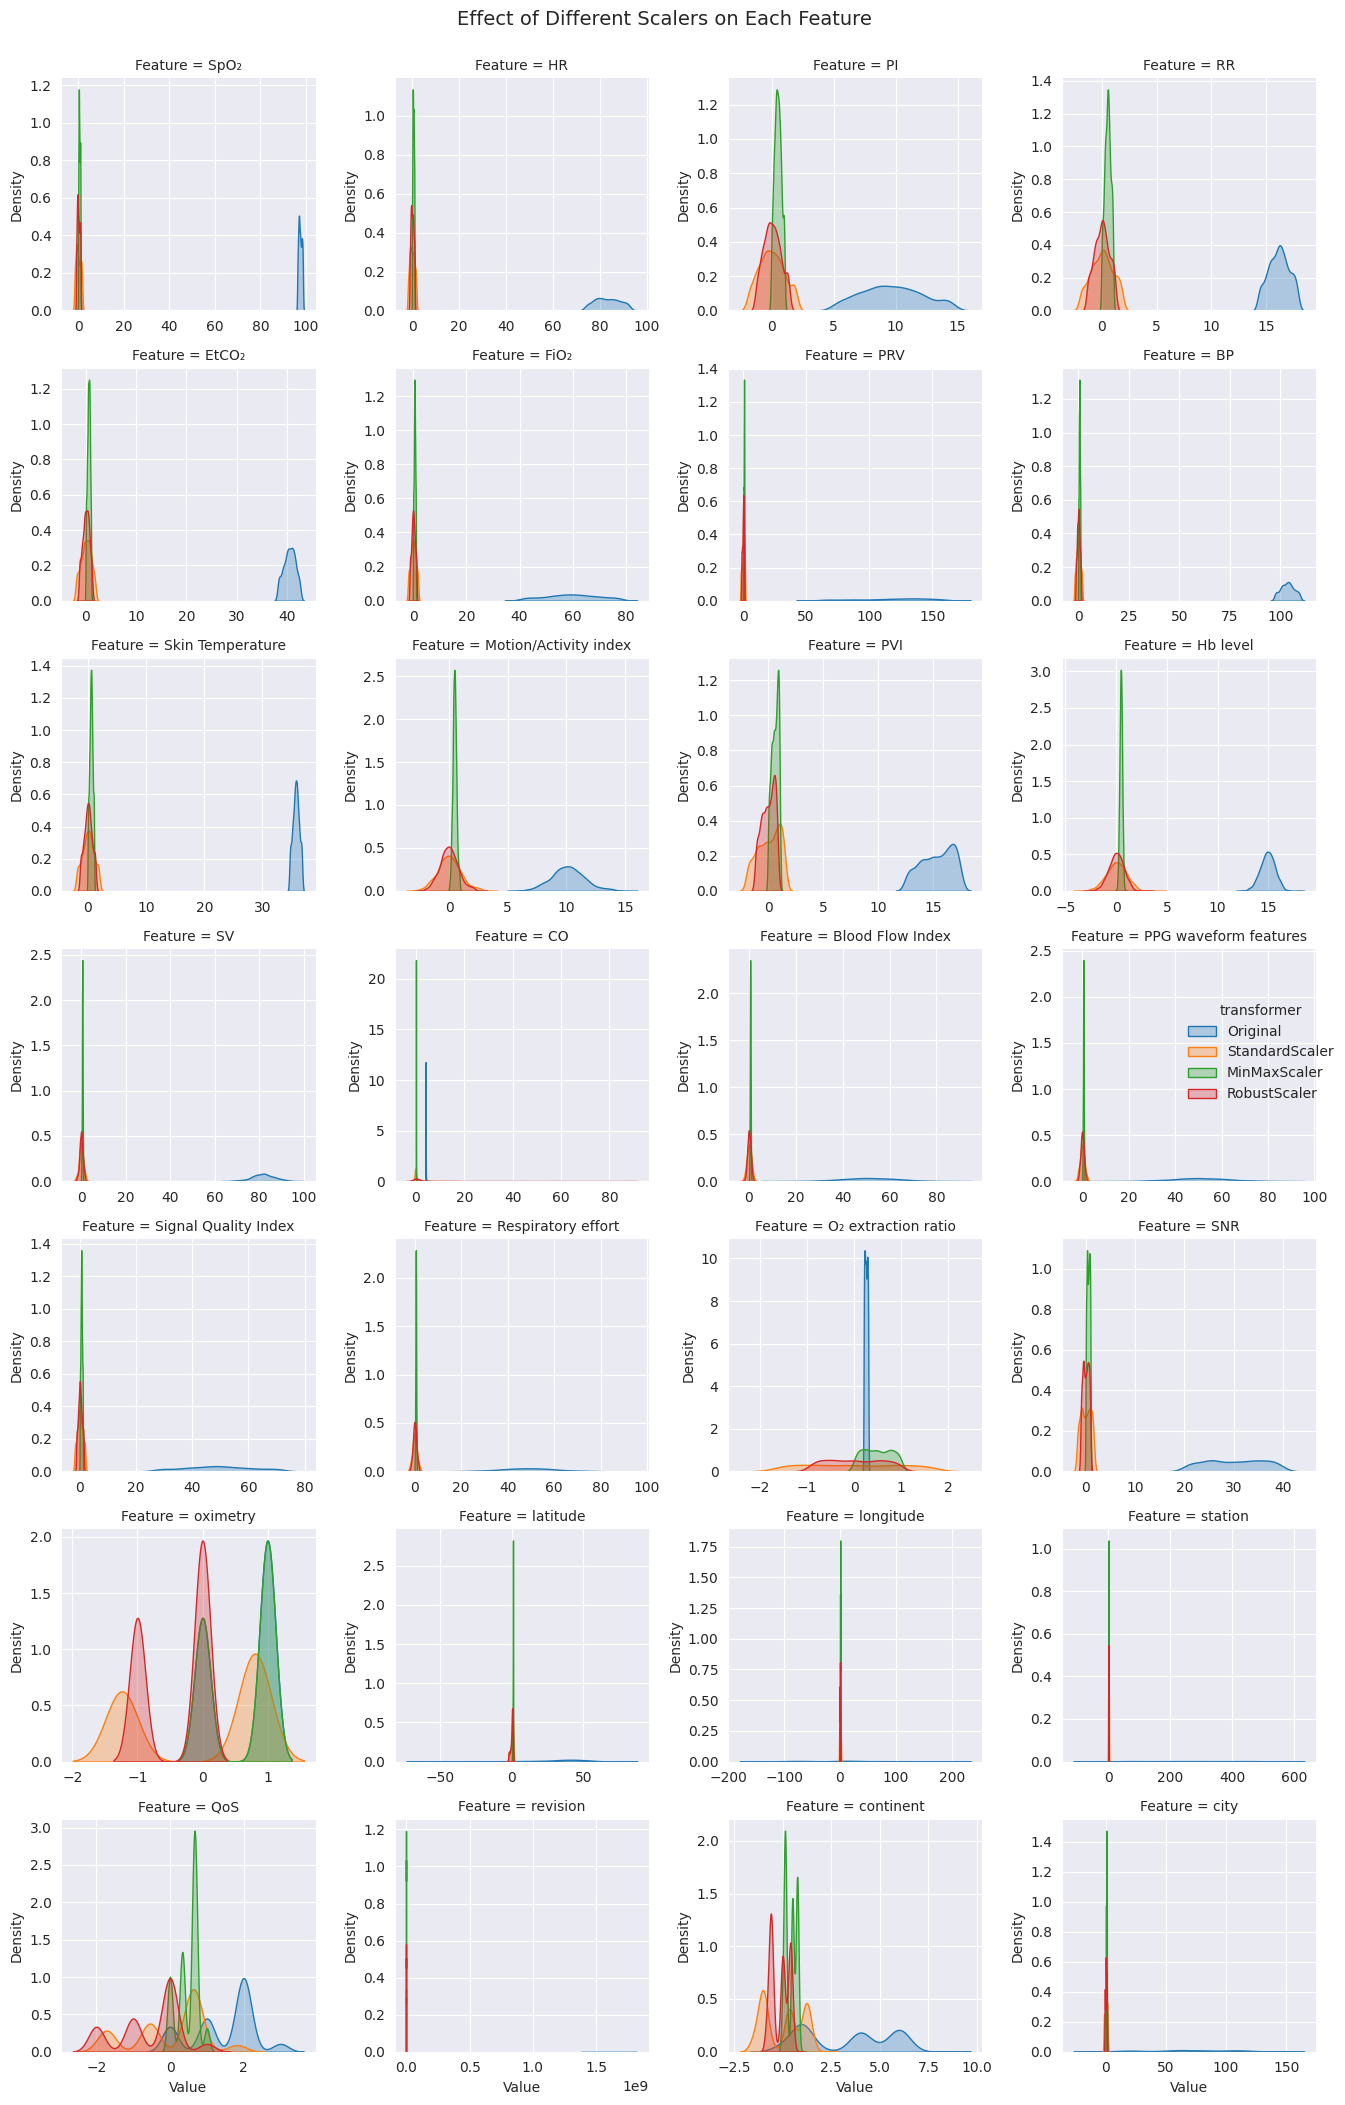

In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

numeric_df = merged_df.select_dtypes(include=[np.number]).dropna()
sample = numeric_df.sample(min(1000, len(numeric_df)), random_state=42)

scalers = {
    "Original": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
}

dfs = []
for name, transformer in scalers.items():
    if transformer is None:
        transformed = sample.copy()
    else:
        transformed = pd.DataFrame(transformer.fit_transform(sample), columns=sample.columns)
    transformed["transformer"] = name
    dfs.append(transformed)

df_all = pd.concat(dfs)
df_melted = df_all.melt(id_vars="transformer", var_name="Feature", value_name="Value")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

g = sns.FacetGrid(df_melted, col="Feature", hue="transformer", col_wrap=4, sharex=False, sharey=False, height=3)
g.map(sns.kdeplot, "Value", fill=True, alpha=0.3)
g.add_legend()
g.fig.suptitle("Effect of Different Scalers on Each Feature", fontsize=14, y=1)
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

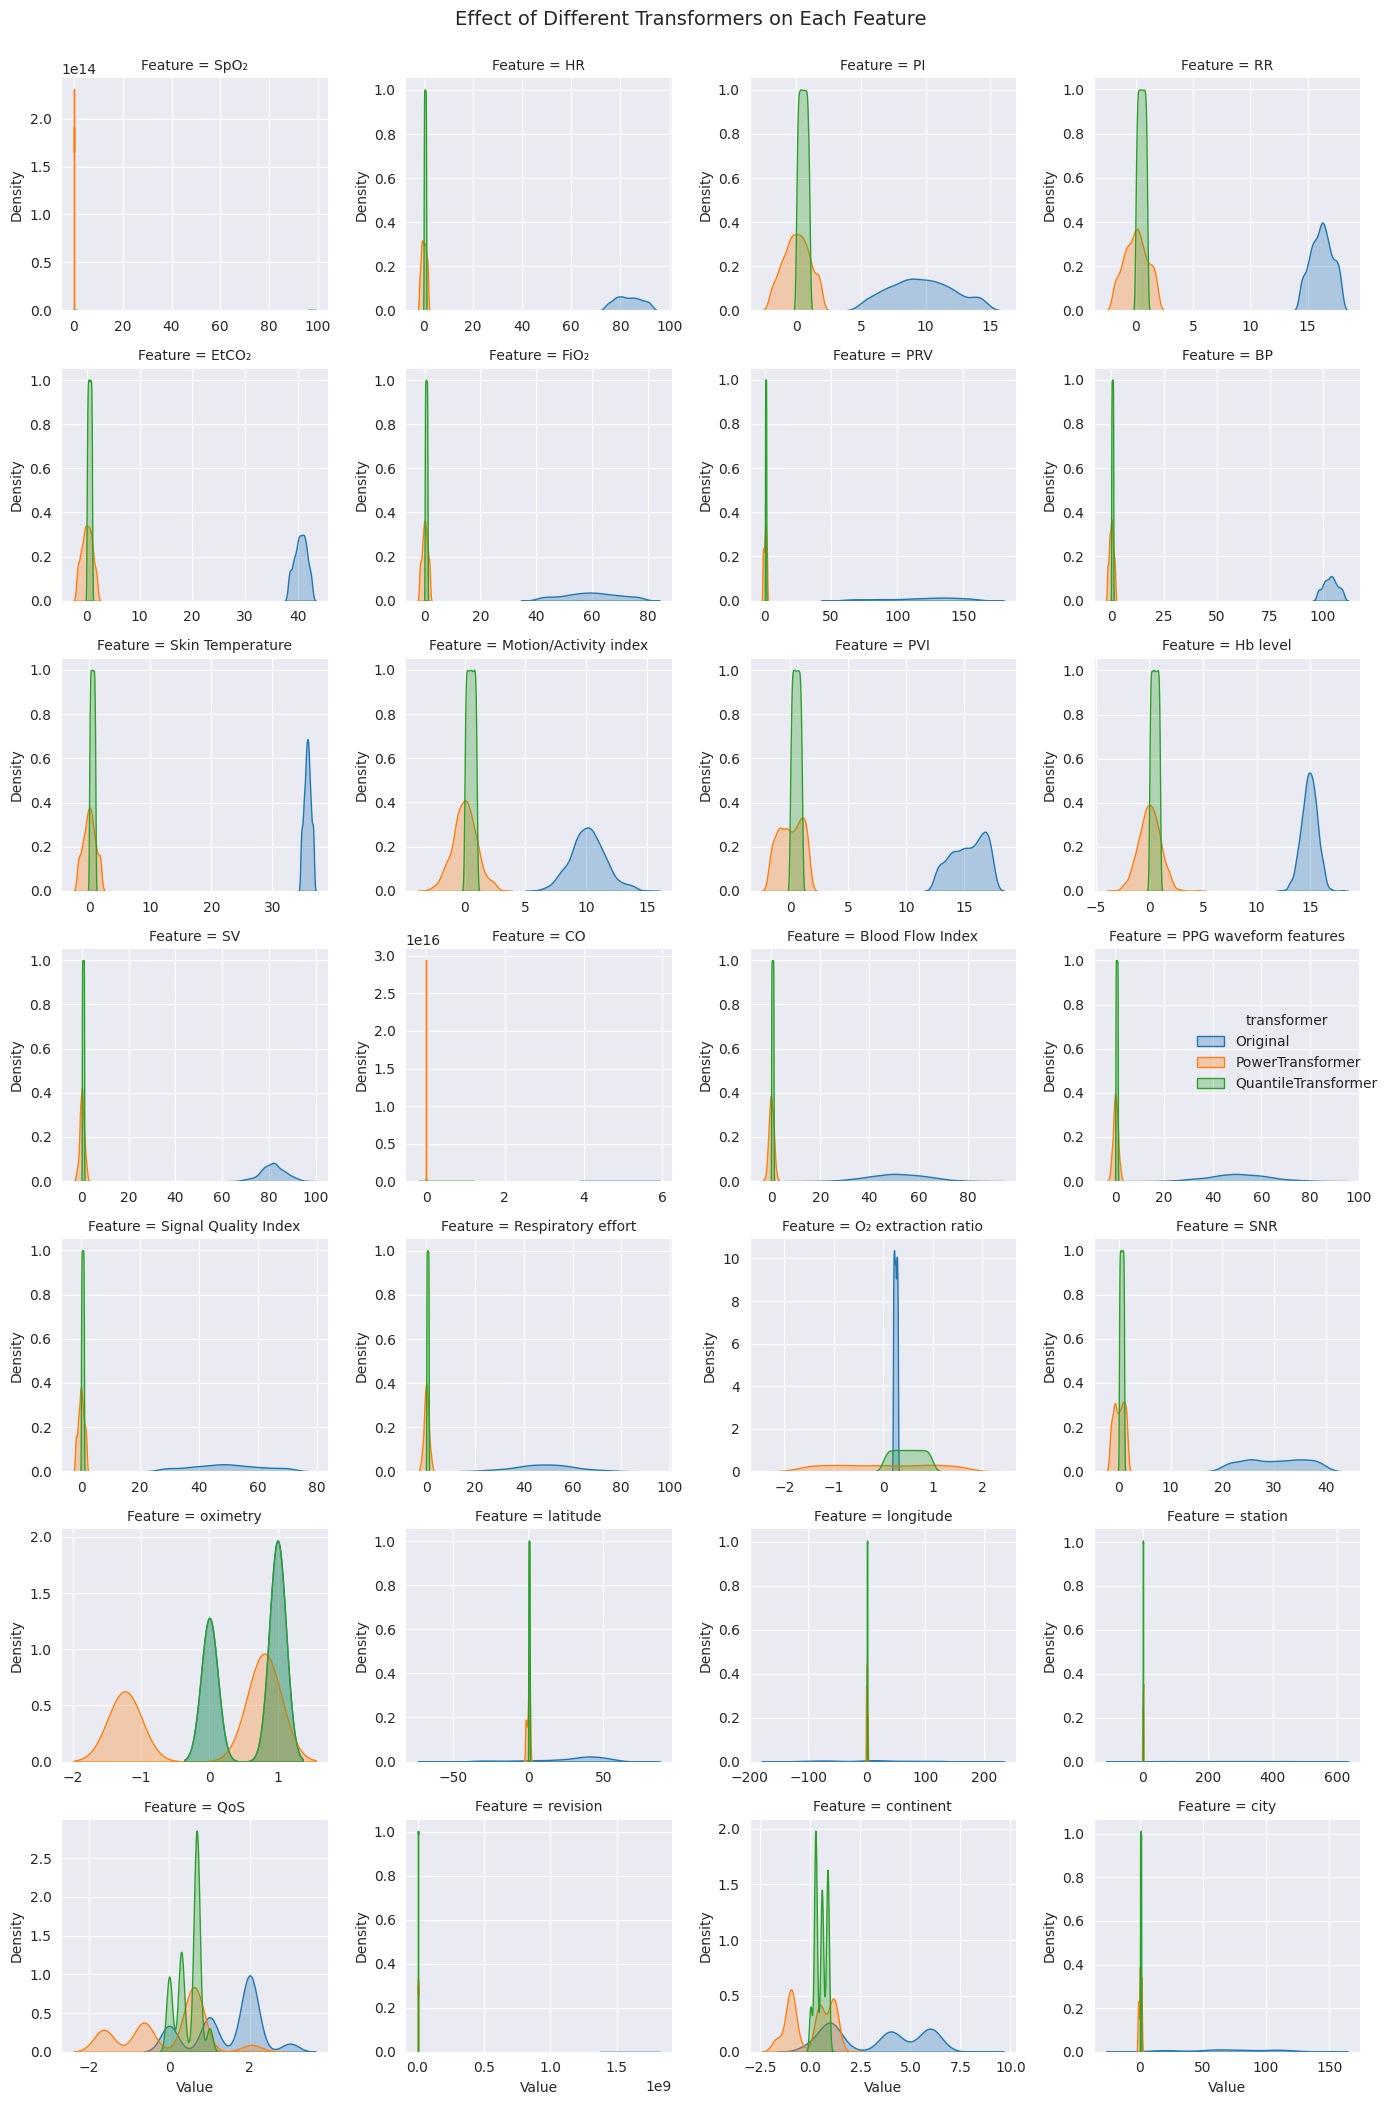

In [117]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

transformers = {
    "Original": None,
    "PowerTransformer": PowerTransformer(),
    "QuantileTransformer": QuantileTransformer(n_quantiles=100, random_state=0),
}

dfs = []
for name, transformer in transformers.items():
    if transformer is None:
        transformed = sample.copy()
    else:
        transformed = pd.DataFrame(transformer.fit_transform(sample), columns=sample.columns)
    transformed["transformer"] = name
    dfs.append(transformed)

df_all = pd.concat(dfs)
df_melted = df_all.melt(id_vars="transformer", var_name="Feature", value_name="Value")

g = sns.FacetGrid(df_melted, col="Feature", hue="transformer", col_wrap=4, sharex=False, sharey=False, height=3)
g.map(sns.kdeplot, "Value", fill=True, alpha=0.3)
g.add_legend()
g.fig.suptitle("Effect of Different Transformers on Each Feature", fontsize=14, y=1)
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

In [ ]:
X = merged_df.drop(columns=['oximetry'])
y = merged_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "PowerTransformer": PowerTransformer(),
    "QuantileTransformer": QuantileTransformer(output_distribution="uniform")
}

selectors = {
    "SelectKBest": SelectKBest(score_func=f_regression, k=10),
    "MutualInfo": SelectKBest(score_func=mutual_info_regression, k=10),
    "VarianceThreshold": VarianceThreshold(0.01)
}

model = RandomForestRegressor(random_state=42, n_estimators=100)

results = []

for scaler_name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for selector_name, selector in selectors.items():
        try:
            X_train_sel = selector.fit_transform(X_train_scaled, y_train)
            X_test_sel = selector.transform(X_test_scaled)

            model.fit(X_train_sel, y_train)
            y_pred = model.predict(X_test_sel)

            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)

            results.append({
                "Scaler": scaler_name,
                "Selector": selector_name,
                "R2 Score": r2,
                "MAE": mae
            })
        except Exception as e:
            print(f"{scaler_name} + {selector_name} failed: {e}")

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df)

In [107]:
X = merged_df.drop(columns=['oximetry'])
y = merged_df['oximetry']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k='all')),
    ('model', LinearRegression())
])

pipeline.fit(X, y)

selector = pipeline.named_steps['select']
mask = selector.get_support()
selected_features = X.columns[mask]

coef = pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coef,
    'Abs_Coeff': abs(coef)
}).sort_values(by='Abs_Coeff', ascending=False)

display(coef_df.head(100))

,Feature,Coefficient,Abs_Coeff
10,PVI,0.261145,0.261145
6,PRV,0.095775,0.095775
1,HR,0.094190,0.094190
4,EtCO₂,-0.051431,0.051431
0,SpO₂,-0.023435,0.023435
25,city,0.008085,0.008085
24,continent,-0.007633,0.007633
18,O₂ extraction ratio,0.006577,0.006577
8,Skin Temperature,0.004596,0.004596
23,revision,0.004319,0.004319
